In [2]:
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import netCDF4 as nc
import datetime
from datetime import timedelta
from pathlib import Path

In [3]:
# Load data 
data_in = 'ARC_EKE.nc'
f = nc.Dataset(data_in)

eke  = f.variables['eke'][:]        # (time, lat, lon)
time  = f.variables['time'][:]
lat   = f.variables['latitude'][:]
lon   = f.variables['longitude'][:]

In [4]:
# Convert CNES time (days since 1950-01-01) → datetime objects 
CNES_EPOCH = datetime.datetime(1950, 1, 1)
datetime_list = [CNES_EPOCH + timedelta(days=float(t)) for t in time]
datetime_array = np.array(datetime_list)           # plain numpy array of datetimes

In [9]:
# max_eke = {}
# for i in datetime_array:
#     for k in lon:
#         max_lat = []
#         max_eke = []
#         for j in lat:
#             if eke[]
            

In [39]:
# Taking the maximum EKE points for each longitude and time point
eke_max = np.max(eke, axis=1)*0.01 # scaled to m^2/s^2
print(np.shape(eke_max)) # shape is (time,lon) # note, the time points in this array are in the original units
print(np.min(eke_max),np.max(eke_max))
eke_max_scaled = eke_max/eke_max[0,0]
print(np.min(eke_max_scaled),np.max(eke_max_scaled))
print(eke_max[0,0])
eke_max_scaled[0,0]

(372, 540)
0.685629 203.194705
0.010230549620938806 3.031950970881515
67.017807


np.float64(1.0)

In [73]:
print(np.max(eke_max[0]))
#print(np.std(eke_max))

67.017807


In [47]:
## Taking the latitude values of the max EKE points to plot contours

# Find the latitude index of max EKE at each (time, lon) point
max_lat_idx = np.argmax(eke, axis=1)        # (time, lon) # instead of taking the max EKE value itself, this function takes the index of the max EKE value

# Convert indices → actual latitude values
max_lat = lat[max_lat_idx]                     # (time, lon) # then we use our indecies to point to the actual latitude values in the latitude array

print(np.shape(max_lat)) # shape is (time,lon)

(372, 540)


In [13]:
output_dir = Path('./ARC_EKE Figures')
output_dir.mkdir(parents=True, exist_ok=True)

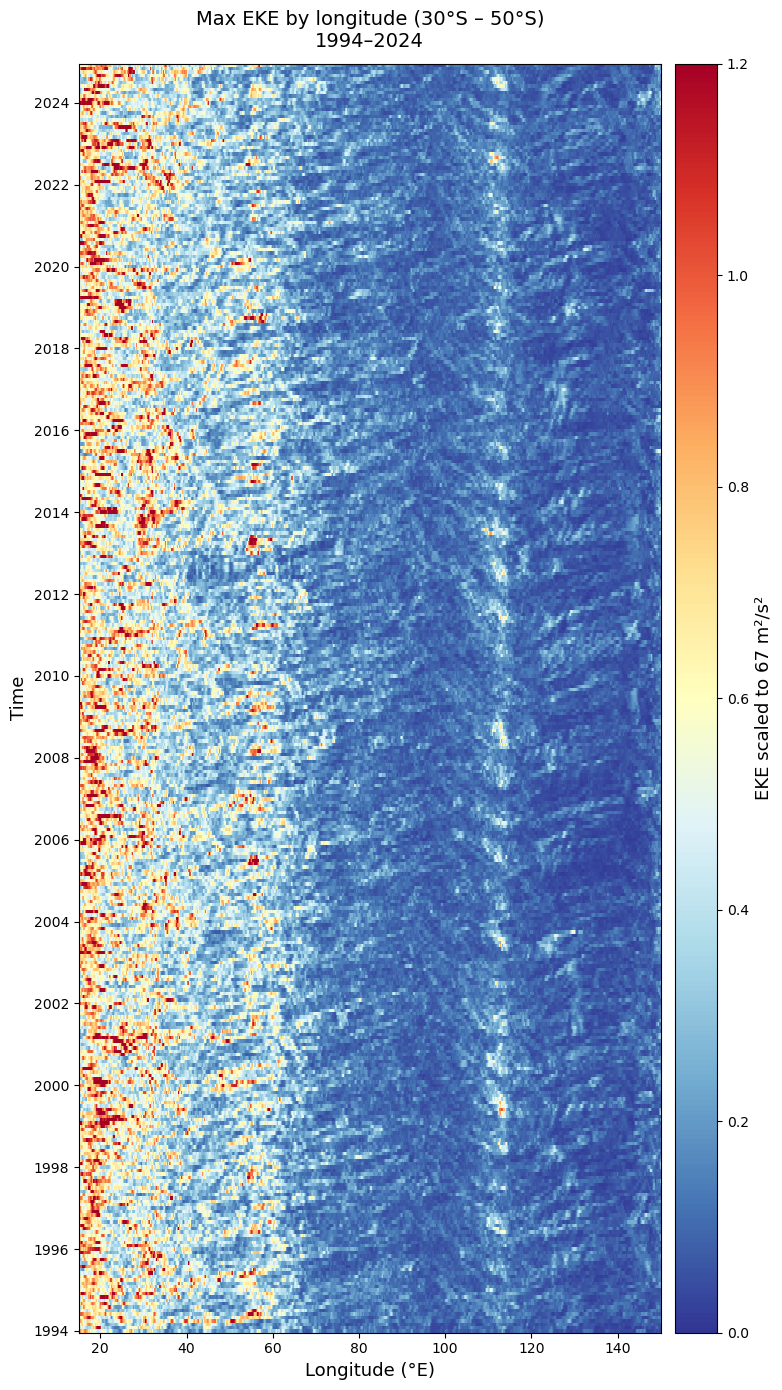

In [86]:
# Build meshgrid
LON, TIME = np.meshgrid(lon, mdates.date2num(datetime_array)) # converts datetime objects to matplotlib time objects

# Plot
fig, ax = plt.subplots(figsize=(8, 14))

pcm = ax.pcolormesh(
    LON, TIME, eke_max_scaled,
    cmap='RdYlBu_r',
    vmin=0, vmax=1.2,
    shading='auto',
)

# contour = ax.contour(
#     LON, TIME, eke_max_scaled,
#     levels = 10,
#     colors = 'black',
#     linewidths = 0.8,
#     linestyles = 'solid',
# )

# # Add latitude contours 
# contour = ax.contour(
#     LON, TIME, max_lat,
#     levels=1,                   
#     colors='black',
#     linewidths=0.5,
#     linestyles='solid',
# )
# ax.clabel(contour, inline=True, fontsize=12, fmt='%.1f')

# Colorbar
cbar = fig.colorbar(pcm, ax=ax, pad=0.02, aspect=30)
cbar.set_label('EKE scaled to 67 m²/s²', fontsize=13)

# Time axis (y-axis) — one tick per year
ax.yaxis_date()
ax.yaxis.set_major_locator(mdates.YearLocator(2))
ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Labels
ax.set_xlabel('Longitude (°E)', fontsize=13)
ax.set_ylabel('Time', fontsize=13)
ax.set_title(
    'Max EKE by longitude (30°S – 50°S)\n'
    '1994–2024',
    fontsize=14, pad=12,
)

plt.tight_layout()
filename = output_dir / f'ARC_EKE_Hovmoller3.png'
plt.savefig(filename, dpi=150, bbox_inches='tight')
plt.show()

#f.close()

In [ ]:
# # Select subset 37.5S–42.5S, 20E–40E for EKE hotspot at retroflection
# # Select subset 40S -45S, 50E-70E for EKE hotspot around Kerguelen Plateau
# latmin,latmax = -45,-40
# lonmin,lonmax = 50,70

# lat_mask = (lat >= latmin) & (lat <= latmax)
# lon_mask = (lon >=  lonmin) & (lon <= lonmax)

# eke_subset = eke[:, lat_mask, :][:, :, lon_mask]  # (time, lat_sub, lon_sub)
# lon_sub    = lon[lon_mask]
# lat_sub    = lat[lat_mask]

# # Average over latitude → (time, longitude) 
# eke_hovmoller = np.mean(eke_subset, axis=1)        # (time, lon_sub)

# # Scale to m²/s² 
# eke_hovmoller_scaled = eke_hovmoller * 0.01

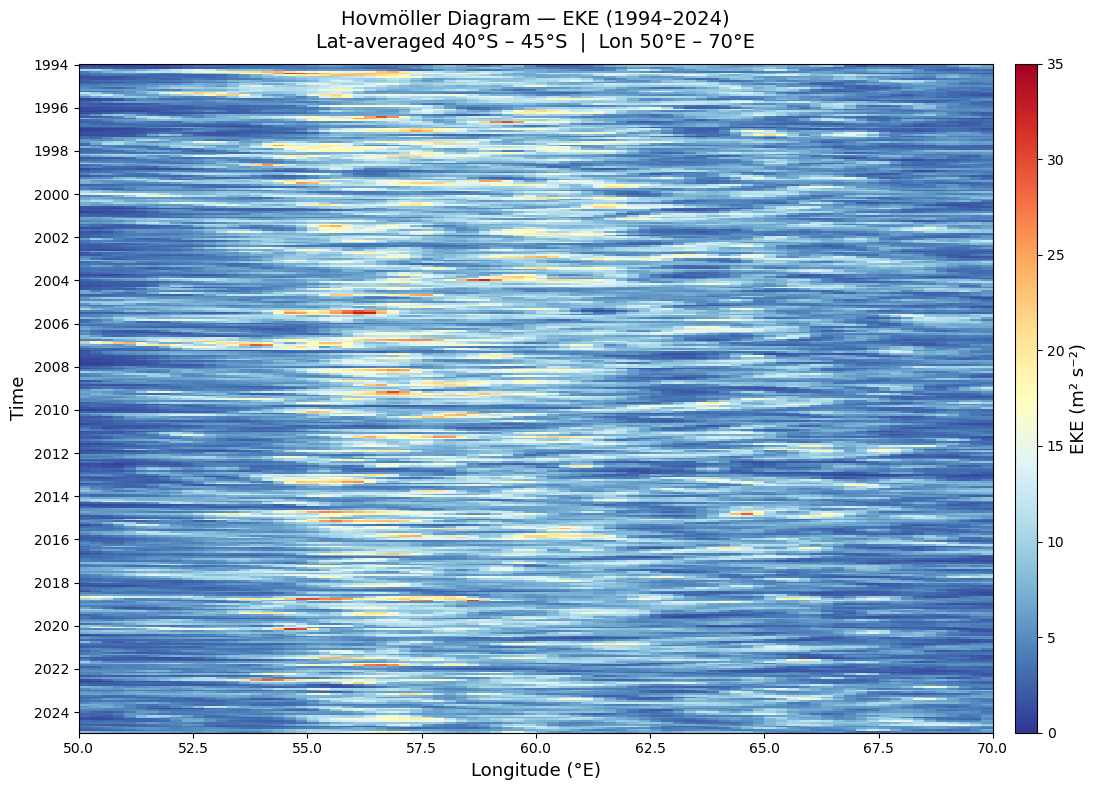

In [ ]:
# # Build meshgrid
# LON, TIME = np.meshgrid(lon_sub, mdates.date2num(datetime_array)) # converts datetime objects to matplotlib time objects

# # Plot
# fig, ax = plt.subplots(figsize=(12, 8))

# pcm = ax.pcolormesh(
#     LON, TIME, eke_hovmoller_scaled,
#     cmap='RdYlBu_r',
#     vmin=0, vmax=35,
#     shading='auto',
# )

# # Colorbar
# cbar = fig.colorbar(pcm, ax=ax, pad=0.02, aspect=30)
# cbar.set_label('EKE (m² s⁻²)', fontsize=13)

# # Time axis (y-axis) — one tick per year
# ax.yaxis_date()
# ax.yaxis.set_major_locator(mdates.YearLocator(2))
# ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# ax.invert_yaxis()                                  # oldest at top

# # Labels
# ax.set_xlabel('Longitude (°E)', fontsize=13)
# ax.set_ylabel('Time', fontsize=13)
# ax.set_title(
#     'Hovmöller Diagram — EKE (1994–2024)\n'
#     'Lat-averaged 40°S – 45°S  |  Lon 50°E – 70°E',
#     fontsize=14, pad=12,
# )

# plt.tight_layout()
# filename = output_dir / f'ARC_EKE_Hovmoller2.png'#
# plt.savefig(filename, dpi=150, bbox_inches='tight')
# plt.show()

# #f.close()